In [1]:
library(tidyverse)
library(ggplot2)
library(ggrepel)
library(dplyr)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
df_all <- read.csv("data/snRNA_data/DEG/Retinal ganglion cell.csv", stringsAsFactors = FALSE)

In [3]:
df <- data.frame(gene=NULL,logFC=NULL,padj=NULL,time=NULL)

In [4]:
for(i in c('2w','4w','8w')){
    deg <- df_all[,c(paste0('COH_',i,'_names'),paste0('COH_',i,'_logfoldchanges'),paste0('COH_',i,'_pvals_adj'))]
    colnames(deg) <- c('gene','logFC','padj')
    deg <- deg[deg$gene %in% c('Piezo1','Piezo2','Kcnk2','Kcnk4','Kcnk10','Trpv1','Trpv2','Trpv4','Trpm3','Trpm4','Trpm7'),] %>% mutate(time=paste0('COH_',i))
    df <- rbind(df,deg)
}

In [5]:
df <- df %>%
  mutate(
    neglog10_padj = -log10(padj),
    group = case_when(
      padj < 0.01 & logFC >= 0.25  ~ "Up",
      padj < 0.01 & logFC <= -0.25 ~ "Down",
      TRUE                        ~ "NS"
    )
  )

In [6]:
df <- df %>%
  mutate(
    color_group = ifelse(group == "NS", "NS", as.character(time))
  )

In [7]:
df_label <- df[df$group %in% c("Up", "Down"), ]

Ignoring unknown labels:
• shape : "Time"


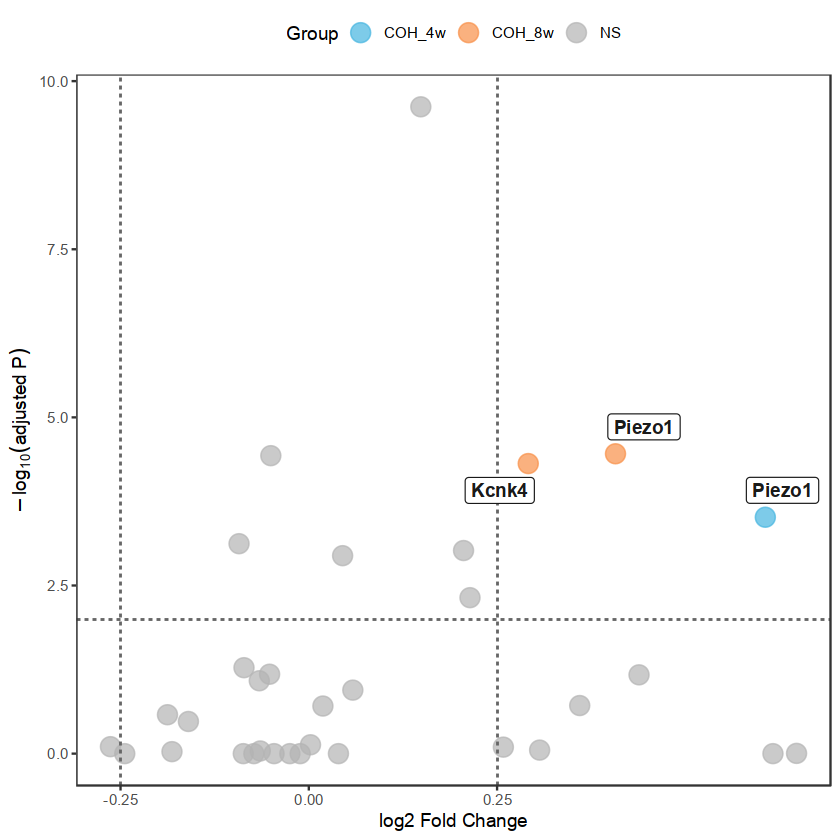

In [8]:
ggplot(df, aes(x = logFC, y = neglog10_padj)) +
  geom_point(aes(color = color_group), size = 5, alpha = 0.7) +
  geom_vline(xintercept = c(-0.25, 0.25), color = "grey40", linetype = "dashed", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.01), color = "grey40", linetype = "dashed", linewidth = 0.6) +
  geom_label_repel(
    data = df_label,
    aes(label = gene), 
    fontface = "bold", 
    color = "grey10", 
    box.padding = unit(0.5, "lines"), 
    point.padding = unit(0.3, "lines"), 
    segment.colour = "grey30",
    max.overlaps = 20
  ) +
  scale_color_manual(
    values = c("COH_4w" = "#45B4E0", "COH_8w" = "#F79048", "NS" = "grey70")
  ) +
  labs(
    x = "log2 Fold Change",
    y = expression(-log[10]("adjusted P")),
    color = "Group",
    shape = "Time"
  ) + 
  scale_x_continuous(
    breaks = c(-0.25,0,0.25)
  ) +
  theme_bw() +
  theme(legend.position = "top",panel.grid.major = element_blank(),panel.grid.minor = element_blank())